In [1]:
from PIL import Image
import numpy as np
import os
import sys

sys.path.append("/home/alberto/UnReflectAnything/")
from utilities.visualization import rgb, panelize
import torch
from dataset.scrream import SCRREAM
from rich import print
%load_ext autoreload
%autoreload 2


dataset = SCRREAM(
        root_dir="/datasets/SCRREAM/",
        rho_s=0.6,
        eps=1e-8
    )
    
# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

from models import DINOv3
from models import TransformerInpaintingDecoder

dinov3 = DINOv3({'return_as_feature_maps': True}).cuda()
decoder = TransformerInpaintingDecoder({'feature_dim': 768, 'hidden_dim': 512}).cuda()

# Test loading a batch
for batch in dataloader:
    
    features = dinov3(dinov3.preprocess_image(batch["rgb"]).cuda())['last_hidden_state']  # [B, 768, 56, 56]
    reconstructed = decoder(features, patch_h=56, patch_w=56)
    reconstructed.shape
    break

# rgb(batch["rgb"][0],colormap="hsv")


In [36]:
from models import DINOv3, DINOv3toDPTRGB

dinov3_config = {
    'model_name': "facebook/dinov3-vitb16-pretrain-lvd1689m",
    'image_size': 896,  # or any size divisible by 16
    'freeze_backbone': True,
    'return_selected_layers': [2, 5, 8, 11],  # DPT extraction points
    'return_as_feature_maps': True  # Need tokens for reassembly
}
dinov3_model = DINOv3(dinov3_config)

# Create the complete model with RGB decoder
model = DINOv3toDPTRGB(
    dinov3_model=dinov3_model,
    decoder_config={
        'use_bn': True,  # Use batch norm for training stability
        'readout_type': 'project'  # or 'project' for global context
    },
    selected_layers=[2, 5, 8, 11]  # Standard DPT layers
).cuda()

In [ ]:
# input_images = torch.randn(4, 3, 896, 896).cuda()  # [B, 3, H, W]
input_img = model.dinov3.preprocess_image(batch["rgb"]).cuda()
input_rgb_unp = batch["rgb"]
rgb_output = model(input_img)  # [B, 3, H, W] in [0, 1] range
featus = model.dinov3(input_img)["last_hidden_state"]

In [44]:
batch["rgb"].min(),batch["rgb"].max(),rgb_output.min(),rgb_output.max()

(tensor(0.),
 tensor(1.),
 tensor(0.1514, device='cuda:0', grad_fn=<MinBackward1>),
 tensor(0.8917, device='cuda:0', grad_fn=<MaxBackward1>))

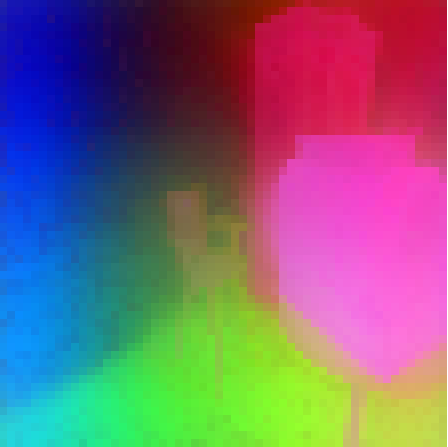

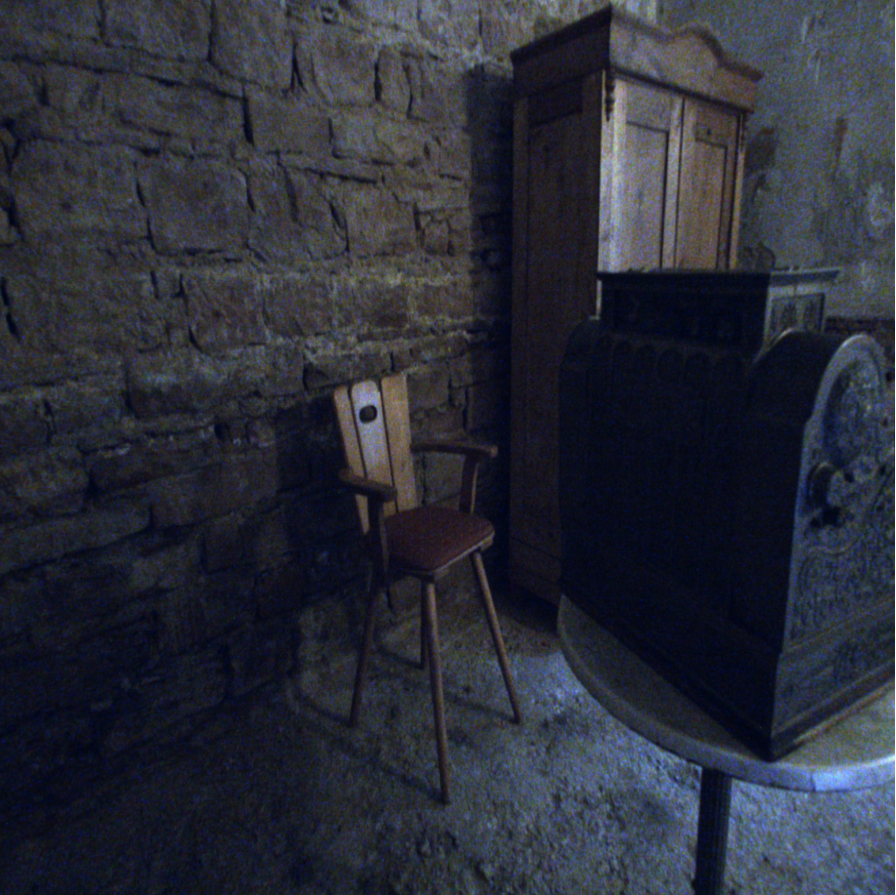

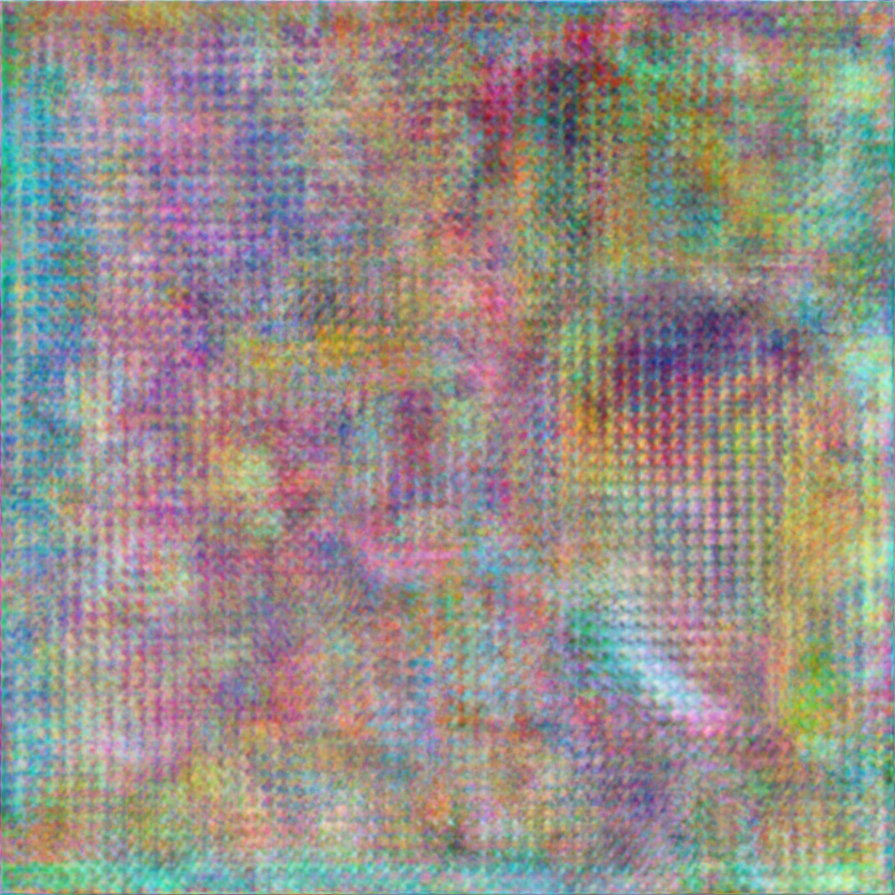

In [38]:
from utilities import embedding2chw
rgb(embedding2chw(featus[:,5:]),scale=8)
rgb(input_img[0])
rgb(rgb_output[0])

In [35]:
total_params = sum(param.numel() for param in model.dinov3.parameters())
reg_params = sum(param.numel() for param in model.dinov3.parameters() if param.requires_grad)

print(total_params, reg_params)

total_params = sum(param.numel() for param in model.decoder.parameters())
reg_params = sum(param.numel() for param in model.decoder.parameters() if param.requires_grad)

print(total_params, reg_params)

85660416 0

13338819 13338819

In [11]:
dinoout = model(model.preprocess_image(batch["rgb"]).cuda())

In [7]:
from models import DINOv3
from models import TransformerInpaintingDecoder

dinov3 = DINOv3({'return_as_feature_maps': True}).cuda()
decoder = TransformerInpaintingDecoder({'feature_dim': 768, 'hidden_dim': 512}).cuda()


In [8]:

features = dinov3(dinov3.preprocess_image(batch["rgb"]).cuda())['last_hidden_state']  # [B, 768, 56, 56]
reconstructed = decoder(features, patch_h=56, patch_w=56)
reconstructed.shape

torch.Size([1, 3, 896, 896])